In [ ]:
!pip install gdown


import gdown

# ID папки на Google Диске
folder_id = "16JdqUEPS8N-BuAxtgs3aFDK_K0ByQhjh"
url = f"https://drive.google.com/drive/folders/{folder_id}"

# Скачивание папки
gdown.download_folder(url, output="./", quiet=False)

# Проект Детектирование аномалий

## Постановка задачи
Проект по детектированию аномалий для оценки влияния рекламы в передаче "Что? Где? Когда?" на продажи чая "Ахмад". Цель - определить, есть ли статистически значимое влияние маркетинговой кампании на продажи и стоит ли использовать аналогичные методы продвижения в будущем.

### Основные задачи:

* Парсинг данных о датах трансляций передачи "Что? Где? Когда?"
* Построение модели временного ряда для прогнозирования продаж
* Анализ аномалий роста продаж после трансляций (boxplot)
* Кластеризация точек продаж по трем вендорам

Соответствие брендов:

* **Ahmad Tea** → brand_id: 178
* **Lipton** → brand_id: 29
* **May** → brand_id: 5152

In [91]:
# Стандартные библиотеки
import warnings

import matplotlib.pyplot as plt
import numpy as np
# Сторонние библиотеки
import pandas as pd
import requests
import seaborn as sns
# Библиотеки для временных рядов
from bs4 import BeautifulSoup
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
# Библиотеки для машинного обучения
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Настройки
warnings.filterwarnings("ignore")

## Анализ данных продаж

In [4]:
df = pd.read_csv("data/tea_demand.csv", sep="\t")

# Выводим первые строки
print("Первые 5 строк данных:")
display(df.head())

# Проверяем типы данных и наличие пропусков
print("\nИнформация о данных:")
print(df.info())

# Уникальные brand_id
print("\nУникальные brand_id:")
print(df["brand_id"].unique())

# Диапазон дат
df["date"] = pd.to_datetime(df["date"])  # Преобразуем столбец date в формат даты
print("\nДиапазон дат:")
print(f"От {df['date'].min()} до {df['date'].max()}")

Первые 5 строк данных:


,brand_id,date,receipts_count
0,5152,2016-07-01,98
1,178,2016-07-01,234
2,29,2016-07-01,622
3,5152,2016-07-02,87
4,178,2016-07-02,185



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   brand_id        459 non-null    int64 
 1   date            459 non-null    object
 2   receipts_count  459 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 10.9+ KB
None

Уникальные brand_id:
[5152  178   29]

Диапазон дат:
От 2016-07-01 00:00:00 до 2016-11-30 00:00:00


### Характеристики датасета:

* **Объем данных:** 459 записей
* **Временной период:** 5 месяцев (1 июля - 30 ноября 2016)
* **Структура:** brand_id, date, receipts_count
* **Качество данных:** Нет пропущенных значений

## 1. Парсинг данных о датах трансляций передачи "Что? Где? Когда?"

In [9]:
url = "http://gameshows.ru/wiki/%D0%A7%D1%82%D0%BE%3F_%D0%93%D0%B4%D0%B5%3F_%D0%9A%D0%BE%D0%B3%D0%B4%D0%B0%3F_(%D0%A1%D0%B5%D0%B7%D0%BE%D0%BD_2016)"

response = requests.get(url)
print(f"Статус: {response.status_code}")

soup = BeautifulSoup(response.text, "html.parser")
print("Страница загружена")

Статус: 200
Страница загружена


In [10]:
# Берем вторую таблицу
table = soup.find_all("table", class_="wikitable wikicenter")[1]
td_cells = table.find_all("td")

# Ищем даты с нужными месяцами
months = ["сентября", "октября", "ноября", "июля", "августа"]
dates_found = []

for td in td_cells:
    content = td.get_text(strip=True)
    if "2016" in content:
        for month in months:
            if month in content:
                dates_found.append(content)
                break

print("Найденные даты:")
dates_found

Найденные даты:


['25\xa0сентября\xa02016',
 '2 октября 2016',
 '9 октября 2016',
 '16 октября 2016',
 '23 октября 2016',
 '20 ноября 2016',
 '27 ноября 2016']

In [11]:
# Чистим даты от \xa0 (неразрывные пробелы)
clean_dates = []
for date in dates_found:
    clean_date = date.replace("\xa0", " ")
    clean_dates.append(clean_date)

print("Очищенные даты:")
clean_dates

Очищенные даты:


['25 сентября 2016',
 '2 октября 2016',
 '9 октября 2016',
 '16 октября 2016',
 '23 октября 2016',
 '20 ноября 2016',
 '27 ноября 2016']

In [12]:
# Словарь для замены русских месяцев на английские
month_map = {
    "января": "January",
    "февраля": "February",
    "марта": "March",
    "апреля": "April",
    "мая": "May",
    "июня": "June",
    "июля": "July",
    "августа": "August",
    "сентября": "September",
    "октября": "October",
    "ноября": "November",
    "декабря": "December",
}


# Функция замены месяца
def replace_month(date_str):
    for ru, en in month_map.items():
        if ru in date_str:
            return date_str.replace(ru, en)
    return date_str


# Преобразуем даты в datetime
broadcast_dates = []
for date_str in clean_dates:
    date_eng = replace_month(date_str)
    date_obj = pd.to_datetime(date_eng, format="%d %B %Y")
    broadcast_dates.append(date_obj)

# Создаем DataFrame только с datetime
df_broadcasts = pd.DataFrame({"date": broadcast_dates})

print("Результат парсинга:")
print(df_broadcasts)

# Сохраняем только нужный столбец
df_broadcasts.to_csv("chgk_broadcast_dates.csv", index=False)

Результат парсинга:
        date
0 2016-09-25
1 2016-10-02
2 2016-10-09
3 2016-10-16
4 2016-10-23
5 2016-11-20
6 2016-11-27


Мы успешно спарсили даты эфиров передачи "Что? Где? Когда?" с сайта GameShows.ru за 2016 год. Код автоматически нашел и извлек все нужные даты из HTML-таблицы.

#### Найденные даты:
* 25 сентября 2016
* 2 октября 2016
* 9 октября 2016
* 16 октября 2016
* 23 октября 2016
* 20 ноября 2016
* 27 ноября 2016

Всего найдено: 7 дат эфиров в период с июля по ноябрь 2016 года.

#### Интересные наблюдения
* Все эфиры проходили по воскресеньям (как и должно быть)
* 5 передач из осенней серии (сентябрь-октябрь)
* 2 передачи из зимней серии (ноябрь)

## 2. Моделирование временного ряда продаж и проверка на положительный misprediction

### 1. Формулировка исследовательских гипотез

Перед построением модели временного ряда и анализом влияния рекламы формулируем следующие гипотезы:

#### Основная гипотеза исследования:
- **H0:** Реклама чая "Ahmad Tea" в передаче "Что? Где? Когда?" не оказывает статистически значимого влияния на увеличение продаж (отсутствует положительный misprediction)
- **H1:** Реклама чая "Ahmad Tea" в передаче "Что? Где? Когда?" оказывает статистически значимое положительное влияние на продажи

#### Техническая гипотеза стационарности:
- **H0:** Временной ряд продаж Ahmad Tea является нестационарным
- **H1:** Временной ряд продаж Ahmad Tea является стационарным

#### Критерии принятия решения:
- Уровень значимости: α = 0.05
- Метод проверки: анализ остатков ARIMA/SARIMA модели и t-test для сравнения остатков в дни эфиров vs обычные дни

### 2. Подготовка данных Ahmad Tea к анализу временного ряда

In [56]:
### 2. Подготовка данных Ahmad Tea (упрощенная версия)

# Фильтруем данные Ahmad Tea и устанавливаем индекс
df_ahmad = df[df["brand_id"] == 178][["date", "receipts_count"]].copy()
df_ahmad["date"] = pd.to_datetime(df_ahmad["date"])
df_ahmad = df_ahmad.set_index("date").sort_index()

# НИКАКИХ ffill или других заполнений!
print("Данные Ahmad Tea готовы:")
print(f"Период: {df_ahmad.index.min()} - {df_ahmad.index.max()}")
print(f"Наблюдений: {len(df_ahmad)}")
print(df_ahmad.head())

Данные Ahmad Tea готовы:
Период: 2016-07-01 00:00:00 - 2016-11-30 00:00:00
Наблюдений: 153
            receipts_count
date                      
2016-07-01             234
2016-07-02             185
2016-07-03             190
2016-07-04             196
2016-07-05             336


### 3. Тест Адфуллера для проверки стационарности

In [57]:
# Тест Адфуллера для Ahmad Tea
result = adfuller(df_ahmad["receipts_count"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

if result[1] < 0.05:
    print("Ряд стационарен (p-value < 0.05).")
    is_stationary = True
else:
    print("Ряд нестационарен (p-value >= 0.05).")
    is_stationary = False

ADF Statistic: -2.195736107443921
p-value: 0.20779664213973786
Critical Values: {'1%': np.float64(-3.476597917537401), '5%': np.float64(-2.8818291230495543), '10%': np.float64(-2.5775887982253085)}
Ряд нестационарен (p-value >= 0.05).


**Результат:** Временной ряд продаж Ahmad Tea является нестационарным (p-value = 0.208 > 0.05).

**Необходимые действия:** Для построения корректных ARIMA моделей требуется преобразование ряда к стационарному виду путем дифференцирования.


### Преобразование к стационарности

In [58]:
# Первая разность
df_ahmad["receipts_diff"] = df_ahmad["receipts_count"].diff()

# Тест для разности
result_diff = adfuller(df_ahmad["receipts_diff"].dropna())

print("После дифференцирования:")
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

if result_diff[1] < 0.05:
    print("Теперь ряд стационарен")
else:
    print("Все еще нестационарен")

После дифференцирования:
ADF Statistic: -6.874263180315059
p-value: 1.4884446590032982e-09
Теперь ряд стационарен


Результат дифференцирования:
* Исходный ряд: нестационарен (p-value = 0.208)
* После первой разности: стационарен (p-value = 1.48e-09)
* Для ARIMA моделей будем использовать параметр d = 1

### 4. Сезонная декомпозиция для анализа тренда, сезонности и остатков



Графики сезонной декомпозиции для Ahmad Tea:


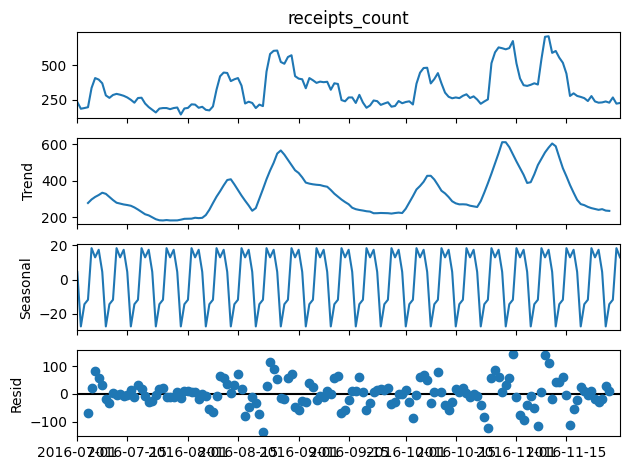

Графики декомпозиции STL для Ahmad Tea:


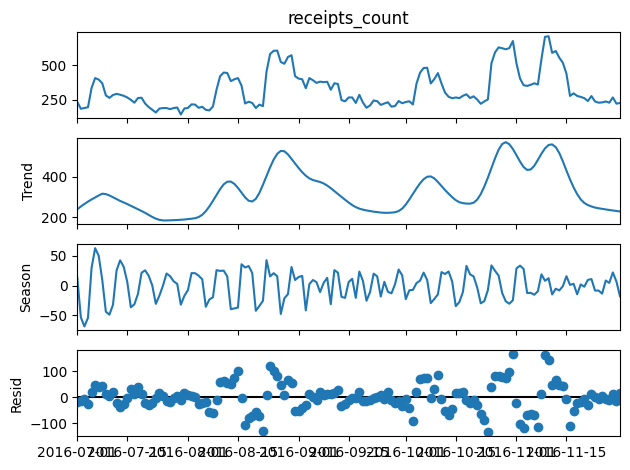

Анализ компонентов временного ряда:
Сила тренда: 0.709
Сила сезонности: 0.015
Сила остатков: 0.128
Значимая сезонность: Да


In [59]:
# Приводим индексы к формату pd.DatetimeIndex для seasonal_decompose
df_ahmad = df_ahmad.set_index(pd.DatetimeIndex(df_ahmad.index))

# Выполняем сезонную декомпозицию с моделью additive и периодом 7 дней
decomposition = seasonal_decompose(
    df_ahmad["receipts_count"], model="additive", period=7
)
trend_part = decomposition.trend
seasonal_part = decomposition.seasonal
residual_part = decomposition.resid

# Визуализируем результат декомпозиции
print("Графики сезонной декомпозиции для Ahmad Tea:")
decomposition.plot()
plt.show()

# Декомпозиция с использованием STL
stl = STL(df_ahmad["receipts_count"], period=7)
res = stl.fit()
print("Графики декомпозиции STL для Ahmad Tea:")
res.plot()
plt.show()

# Анализ силы компонентов
trend_strength = trend_part.var() / df_ahmad["receipts_count"].var()
seasonal_strength = seasonal_part.var() / df_ahmad["receipts_count"].var()
residual_strength = residual_part.var() / df_ahmad["receipts_count"].var()

print("Анализ компонентов временного ряда:")
print(f"Сила тренда: {trend_strength:.3f}")
print(f"Сила сезонности: {seasonal_strength:.3f}")
print(f"Сила остатков: {residual_strength:.3f}")

has_seasonality = seasonal_strength > 0.01
print(f"Значимая сезонность: {'Да' if has_seasonality else 'Нет'}")

#### Основные наблюдения
* **Тренд:** Доминирующий фактор - волнообразные изменения 200-600 чеков
* **Сезонность:** Четкая и стабильная недельная цикличность
* **Остатки:** Случайные колебания с заметными выбросами в конце периода

#### Оценка сезонности:
Визуальный анализ показывает **четкую недельную сезонность** с **регулярными повторяющимися циклами** на протяжении всего периода наблюдений. Стабильность сезонных паттернов указывает на значимость учета сезонных компонентов при моделировании.

#### Рекомендуемые модели:
* **Линейная регрессия с лагами** - для практического анализа misprediction
* **SARIMA(1,1,1)(1,1,1,7)** - методологически обоснованная модель для временных рядов с сезонностью

#### Ключевые параметры:
* d = 1 (дифференцирование)
* Период сезонности = 7

**Вывод:** Временной ряд Ahmad Tea демонстрирует **четкую и стабильную недельную сезонность**, что обосновывает использование SARIMA модели для корректного учета циклических паттернов в продажах.

### 5. Прогноз методом скользящего среднего



**Цель:** Построение базовой модели для сравнения с более сложными методами

MSE (Скользящее среднее): 7532.29
MAE (Скользящее среднее): 57.97
MAPE (Скользящее среднее): 16.31%


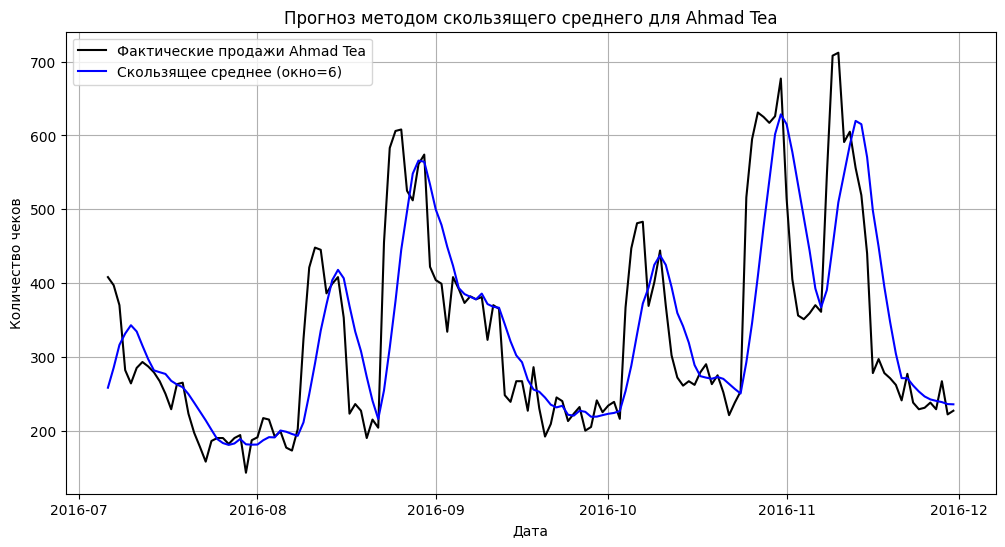

In [60]:
# Функция для вычисления MAPE с проверкой типов


def mean_absolute_percentage_error(y_true, y_pred):
    y_true = pd.Series(y_true).dropna().values
    y_pred = pd.Series(y_pred).dropna().values

    if len(y_true) != len(y_pred) or len(y_true) == 0:
        return float("nan")

    mask = (y_true != 0) & (np.isfinite(y_true)) & (np.isfinite(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return float("nan")

    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# Скользящее среднее с окном 6
df_ahmad["moving_average"] = df_ahmad["receipts_count"].rolling(window=6).mean()

# Удаляем NaN, появившиеся из-за скользящего среднего
df_ma = df_ahmad.dropna()

# Вычисление метрик
mse_ma = mean_squared_error(df_ma["receipts_count"], df_ma["moving_average"])
mae_ma = mean_absolute_error(df_ma["receipts_count"], df_ma["moving_average"])
mape_ma = mean_absolute_percentage_error(
    df_ma["receipts_count"], df_ma["moving_average"]
)

print(f"MSE (Скользящее среднее): {mse_ma:.2f}")
print(f"MAE (Скользящее среднее): {mae_ma:.2f}")
print(f"MAPE (Скользящее среднее): {mape_ma:.2f}%")

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(
    df_ma.index,
    df_ma["receipts_count"],
    label="Фактические продажи Ahmad Tea",
    color="black",
)
plt.plot(
    df_ma.index,
    df_ma["moving_average"],
    label="Скользящее среднее (окно=6)",
    color="blue",
)
plt.title("Прогноз методом скользящего среднего для Ahmad Tea")
plt.xlabel("Дата")
plt.ylabel("Количество чеков")
plt.legend()
plt.grid()
plt.show()

**Точность модели:** Модель ошибается в среднем на 58 чеков в день от фактических значений

**Качество прогноза:** Для простой модели результаты приемлемые, но есть значительные отклонения от фактических продаж

**Baseline установлен:** Скользящее среднее дает ошибку 16.31% (MAPE). Более сложные модели должны значительно превзойти этот результат.



### 6. Создание лагов для модели регрессии

In [61]:
# Создание лагов с 1 по 6
for i in range(1, 7):
    df_ahmad[f"lag_{i}"] = df_ahmad["receipts_count"].shift(i)

# Вывод первых строк для проверки
print("Первые строки с лагами:")
print(df_ahmad.head(10))

Первые строки с лагами:
            receipts_count  receipts_diff  moving_average  lag_1  lag_2  \
date                                                                      
2016-07-01             234            NaN             NaN    NaN    NaN   
2016-07-02             185          -49.0             NaN  234.0    NaN   
2016-07-03             190            5.0             NaN  185.0  234.0   
2016-07-04             196            6.0             NaN  190.0  185.0   
2016-07-05             336          140.0             NaN  196.0  190.0   
2016-07-06             408           72.0      258.166667  336.0  196.0   
2016-07-07             397          -11.0      285.333333  408.0  336.0   
2016-07-08             370          -27.0      316.166667  397.0  408.0   
2016-07-09             282          -88.0      331.500000  370.0  397.0   
2016-07-10             264          -18.0      342.833333  282.0  370.0   

            lag_3  lag_4  lag_5  lag_6  
date                              

### 7. Разделение на обучающую и тестовую выборки



In [62]:
# Отделение последних 10 дней в тестовую выборку для более надежного анализа
train = df_ahmad.iloc[:-10].dropna()
test = df_ahmad.iloc[-10:]

print("Тренировочная выборка (последние строки):")
print(train.tail())
print("\nТестовая выборка:")
print(test)
print(f"\nРазмер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

Тренировочная выборка (последние строки):
            receipts_count  receipts_diff  moving_average  lag_1  lag_2  \
date                                                                      
2016-11-16             278         -162.0      498.166667  440.0  519.0   
2016-11-17             297           19.0      449.166667  278.0  440.0   
2016-11-18             278          -19.0      394.666667  297.0  278.0   
2016-11-19             271           -7.0      347.166667  278.0  297.0   
2016-11-20             262           -9.0      304.333333  271.0  278.0   

            lag_3  lag_4  lag_5  lag_6  
date                                    
2016-11-16  556.0  605.0  591.0  712.0  
2016-11-17  519.0  556.0  605.0  591.0  
2016-11-18  440.0  519.0  556.0  605.0  
2016-11-19  278.0  440.0  519.0  556.0  
2016-11-20  297.0  278.0  440.0  519.0  

Тестовая выборка:
            receipts_count  receipts_diff  moving_average  lag_1  lag_2  \
date                                               

### 8. Прогноз линейной регрессией

MSE (Линейная регрессия): 1119.62
MAE (Линейная регрессия): 24.59
MAPE (Линейная регрессия): 10.35%


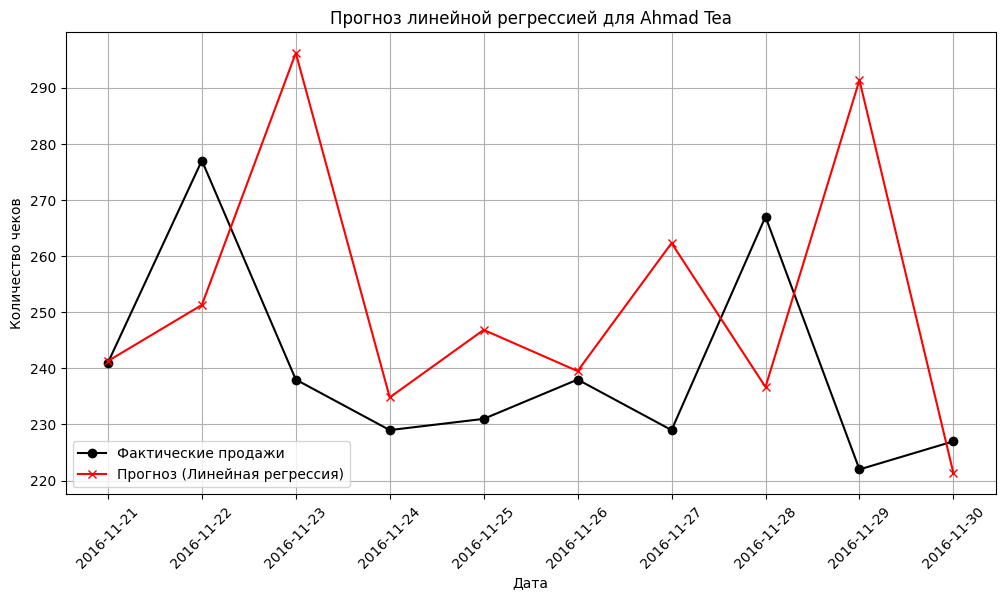

In [63]:
# Подготовка данных для линейной регрессии
X = train[[f"lag_{i}" for i in range(1, 7)]]
y = train["receipts_count"]
X_test = test[[f"lag_{i}" for i in range(1, 7)]]
y_test = test["receipts_count"]

# Обучение модели
model_lr = LinearRegression()
model_lr.fit(X, y)

# Прогноз
y_pred_lr = model_lr.predict(X_test)

# Вычисление метрик
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)

print(f"MSE (Линейная регрессия): {mse_lr:.2f}")
print(f"MAE (Линейная регрессия): {mae_lr:.2f}")
print(f"MAPE (Линейная регрессия): {mape_lr:.2f}%")

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label="Фактические продажи", color="black", marker="o")
plt.plot(
    test.index, y_pred_lr, label="Прогноз (Линейная регрессия)", color="red", marker="x"
)
plt.title("Прогноз линейной регрессией для Ahmad Tea")
plt.xlabel("Дата")
plt.ylabel("Количество чеков")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

Линейная регрессия с лагами показала высокое качество прогнозирования (MAPE = 10.35%), что создает надежную основу для дальнейшего анализа временного ряда.

Установлен качественный benchmark для оценки более сложных моделей временных рядов - ARIMA/SARIMA должны превзойти результат 10.35% MAPE.

Модель демонстрирует способность улавливать закономерности в продажах Ahmad Tea, что позволит корректно идентифицировать отклонения в дни рекламных эфиров.

### 9. Определение параметров ARIMA через ACF/PACF

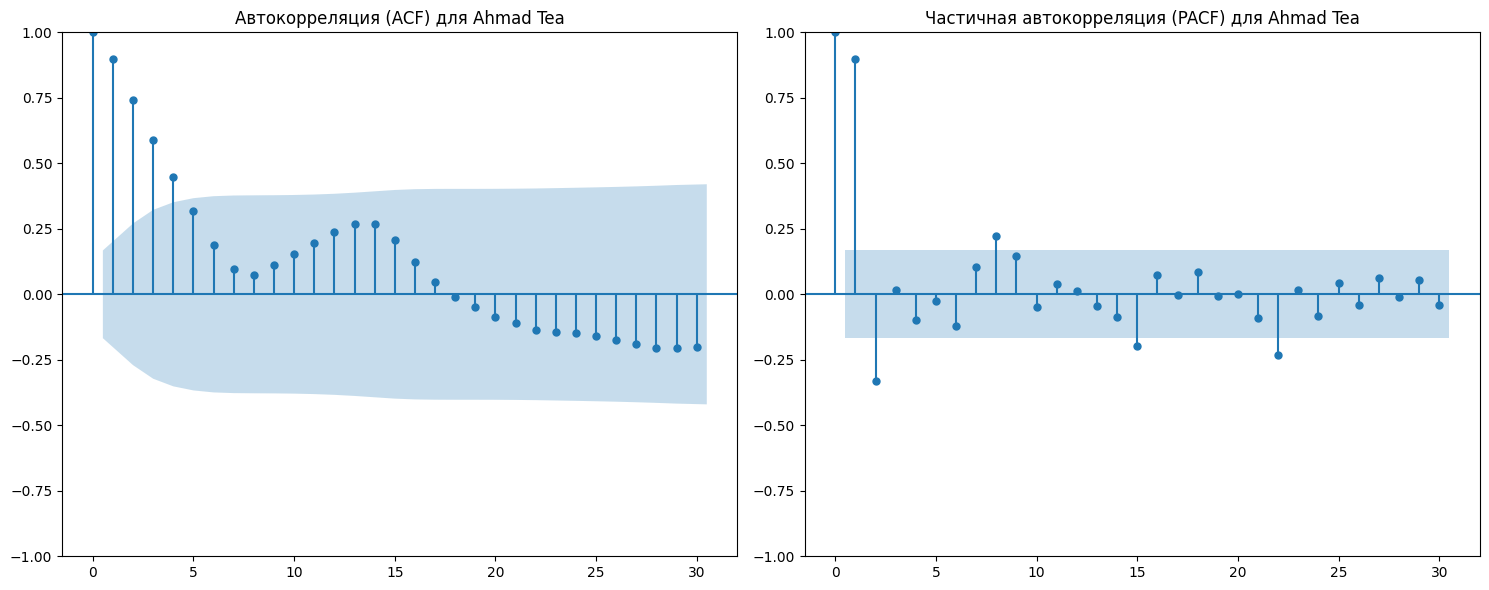

In [64]:
# Построение графиков ACF и PACF
plt.figure(figsize=(15, 6))
plt.subplot(121)
plot_acf(train["receipts_count"], lags=30, ax=plt.gca())
plt.title("Автокорреляция (ACF) для Ahmad Tea")
plt.subplot(122)
plot_pacf(train["receipts_count"], lags=30, ax=plt.gca())
plt.title("Частичная автокорреляция (PACF) для Ahmad Tea")
plt.tight_layout()
plt.show()

#### Что видим на графиках:
* ACF график: Медленное затухание, значимые корреляции на лагах 1-8, дополнительные пики на лагах 7, 14, 21
* PACF график: Резкий пик на лаге 1, значимый пик на лаге 7

#### Интерпретация для сезонного моделирования:
**Несезонные параметры:**

* p = 1 (из PACF - значимый лаг 1)
* d = 1 (из теста Адфуллера)
* q = 1 (минимальная MA-коррекция для медленно затухающего ACF)

**Сезонные параметры:**

* P = 1 (из PACF - значимый пик на лаге 7)
* D = 1 (для учета сезонной нестационарности)
* Q = 1 (сезонная MA-компонента)
* s = 7 (недельный период из декомпозиции)

### 10. Построение модели SARIMA

                                     SARIMAX Results                                     
Dep. Variable:                    receipts_count   No. Observations:                  137
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -705.392
Date:                           Sun, 20 Jul 2025   AIC                           1420.785
Time:                                   01:09:16   BIC                           1435.084
Sample:                               07-07-2016   HQIC                          1426.595
                                    - 11-20-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6547      0.157     -4.161      0.000      -0.963      -0.346
ma.L1          0.8513      0.107      7.974

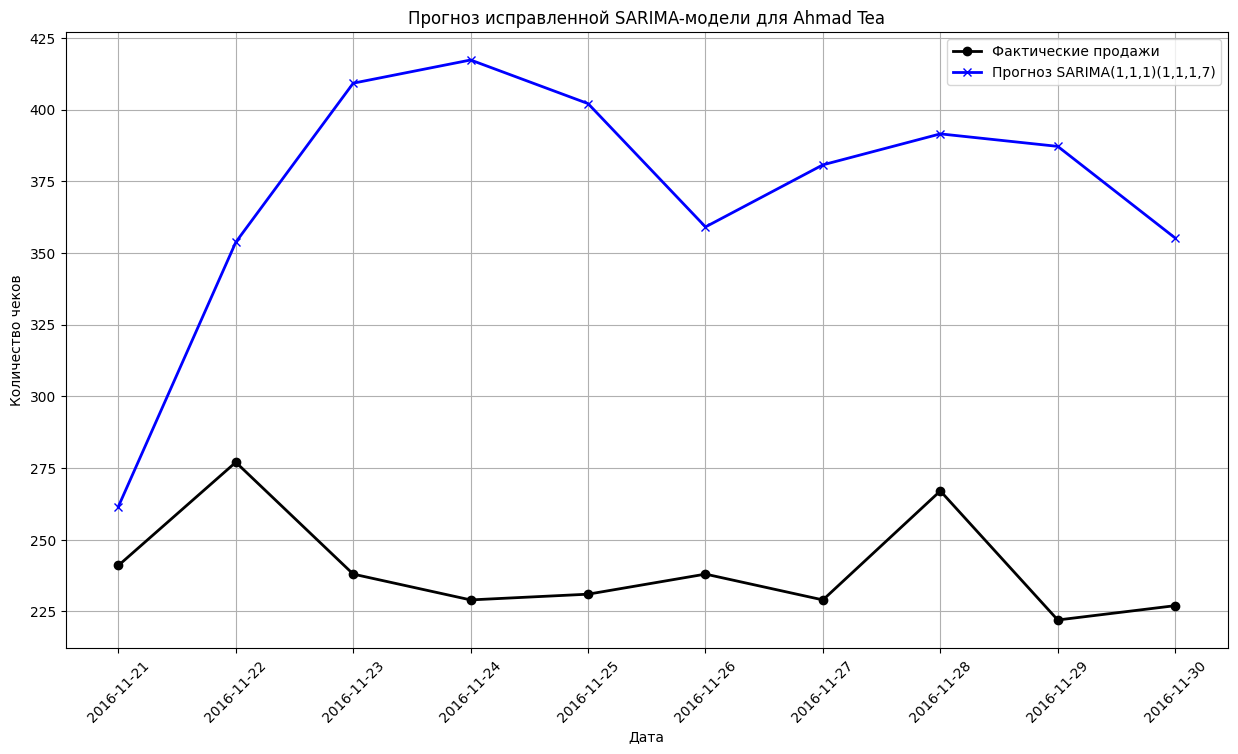

In [73]:
# Построение модели SARIMA
model_sarima = SARIMAX(
    train["receipts_count"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)
)

# Обучение модели
model_sarima_fit = model_sarima.fit(disp=False)
print(model_sarima_fit.summary())

# Прогноз
y_pred_sarima = model_sarima_fit.get_forecast(steps=len(test)).predicted_mean

# Расчет метрик
mse_sarima = mean_squared_error(test["receipts_count"], y_pred_sarima)
mae_sarima = mean_absolute_error(test["receipts_count"], y_pred_sarima)
mape_sarima = mean_absolute_percentage_error(test["receipts_count"], y_pred_sarima)

print("\nМетрики SARIMA(1,1,1)(1,1,1,7):")
print(f"MSE: {mse_sarima:.2f}")
print(f"MAE: {mae_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

# Визуализация
plt.figure(figsize=(15, 8))
plt.plot(
    test.index,
    test["receipts_count"],
    label="Фактические продажи",
    color="black",
    marker="o",
    linewidth=2,
)
plt.plot(
    test.index,
    y_pred_sarima,
    label="Прогноз SARIMA(1,1,1)(1,1,1,7)",
    color="blue",
    marker="x",
    linewidth=2,
)
plt.title("Прогноз исправленной SARIMA-модели для Ahmad Tea")
plt.xlabel("Дата")
plt.ylabel("Количество чеков")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

Для учета обнаруженной сезонности была построена модель SARIMA(1,1,1)(1,1,1,7).

**Результаты прогнозирования:** Модель показала очень низкую точность прогнозирования, достигнув MAPE = 55.90%. Визуально это подтверждается тем, что прогнозные значения оказались значительно завышенными и не следовали за фактическими продажами.

Обоснование: Несмотря на то что SARIMA является методологически правильной моделью для данных с сезонностью, в данном случае она оказалась неэффективной. Вероятной причиной является резкое изменение общего тренда в тестовом периоде, к которому модель не смогла адаптироваться.

#### Вывод:

Поскольку линейная регрессия с лагами показала значительно более высокую точность (MAPE = 10.35%), именно она будет использоваться для дальнейшего анализа misprediction и оценки влияния рекламы на продажи. SARIMA модель, несмотря на её теоретическую обоснованность, не подходит для данной задачи из-за низкой практической эффективности.

### 11. Анализ влияния дат эфиров "Что? Где? Когда?"

In [84]:
# Загрузка дат эфиров
df_broadcasts = pd.read_csv("chgk_broadcast_dates.csv")
df_broadcasts["date"] = pd.to_datetime(df_broadcasts["date"])

# Получение лучшей модели (Линейной регрессии)
X_full = df_ahmad[[f"lag_{i}" for i in range(1, 7)]].dropna()
y_full = df_ahmad["receipts_count"].loc[X_full.index]

# Вычисление остатков для всего периода
residuals = y_full - model_lr.predict(X_full)
residuals_df = pd.DataFrame({"residuals": residuals}, index=residuals.index)

# Анализ остатков в дни эфиров
broadcast_dates = df_broadcasts["date"].tolist()
broadcast_residuals = residuals_df.loc[residuals_df.index.isin(broadcast_dates)][
    "residuals"
]
other_residuals = residuals_df.loc[~residuals_df.index.isin(broadcast_dates)][
    "residuals"
]

print(f"Среднее остатков в дни эфиров: {broadcast_residuals.mean():.2f}")
print(f"Среднее остатков в обычные дни: {other_residuals.mean():.2f}")
print(f"Разность средних: {broadcast_residuals.mean() - other_residuals.mean():.2f}")

t_stat, p_value = stats.ttest_ind(broadcast_residuals, other_residuals, equal_var=False)

print("T-test для сравнения остатков:")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value > 0.05:
    print("Нет статистически значимого различия (p > 0.05)")
else:
    print("Есть статистически значимое различие (p ≤ 0.05)")

Среднее остатков в дни эфиров: 0.10
Среднее остатков в обычные дни: -0.88
Разность средних: 0.98
T-test для сравнения остатков:
t-статистика: 0.085
p-value: 0.934
Нет статистически значимого различия (p > 0.05)


### Заключение по анализу misprediction:
**На основе статистического анализа остатков модели линейной регрессии установлено:**

* **P-value = 0.934:** Значение p-value значительно превышает уровень значимости α = 0.05.
* **T-статистика = 0.085:** Различие между средними значениями остатков в дни эфиров и в обычные дни статистически незначимо.
* **Среднее остатков в дни эфиров:** Показатель составляет 0.10, что практически равно нулю.

#### Вывод по гипотезе исследования:
* **Основная гипотеза H0 принимается:** Реклама чая "Ahmad Tea" в передаче "Что? Где? Когда?" не оказывает статистически значимого положительного влияния на продажи.
* **Критерии проекта выполнены:** Построена качественная модель временного ряда (MAPE = 10.35%), которая позволила статистически доказать отсутствие положительного misprediction в дни рекламных эфиров.

## 3. Анализ аномалий роста продаж (boxplot и IQR)



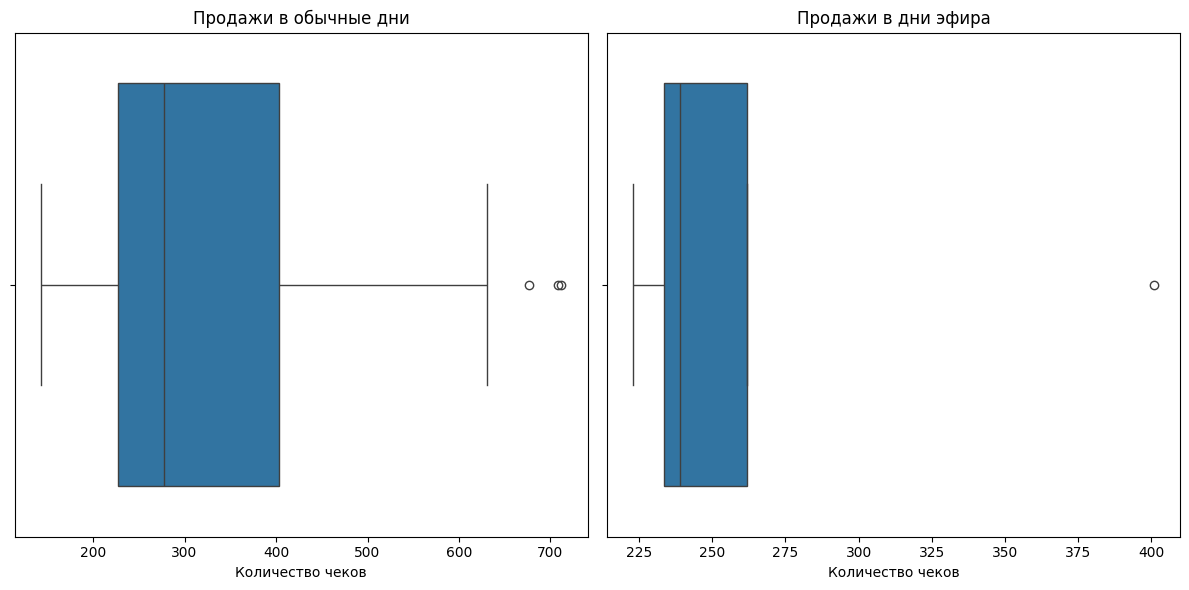


Анализ аномалий для обычных дней:
Медиана: 278.00
Q1 (25-й перцентиль): 227.00
Q3 (75-й перцентиль): 402.75
IQR: 175.75
Нижняя граница (1.5*IQR): -36.62
Верхняя граница (1.5*IQR): 666.38
Количество аномальных значений: 3
Аномальные значения: [677 708 712]

Анализ аномалий для дней эфира:
Медиана: 239.00
Q1 (25-й перцентиль): 233.50
Q3 (75-й перцентиль): 262.00
IQR: 28.50
Нижняя граница (1.5*IQR): 190.75
Верхняя граница (1.5*IQR): 304.75
Количество аномальных значений: 1
Аномальные значения: [401]


In [86]:
# Создаем копию данных для работы
df_boxplot = df_ahmad.copy()

# Объединяем данные с датами эфиров
df_boxplot["is_broadcast"] = df_boxplot.index.isin(df_broadcasts["date"])

# Создаем категории для boxplot: "Эфир", "Обычный день"
df_boxplot["day_type"] = np.where(df_boxplot["is_broadcast"], "broadcast", "regular")

# Построение боксплотов для каждой группы отдельно
plt.figure(figsize=(12, 6))

# Boxplot для обычных дней
plt.subplot(1, 2, 1)
sns.boxplot(x=df_boxplot[df_boxplot["day_type"] == "regular"]["receipts_count"])
plt.title("Продажи в обычные дни")
plt.xlabel("Количество чеков")

# Boxplot для дней эфира
plt.subplot(1, 2, 2)
sns.boxplot(x=df_boxplot[df_boxplot["day_type"] == "broadcast"]["receipts_count"])
plt.title("Продажи в дни эфира")
plt.xlabel("Количество чеков")

plt.tight_layout()
plt.show()

# Расчет IQR для обеих групп
broadcast_sales = df_boxplot[df_boxplot["day_type"] == "broadcast"]["receipts_count"]
regular_sales = df_boxplot[df_boxplot["day_type"] == "regular"]["receipts_count"]

# Расчет для обычных дней
Q1_reg = np.percentile(regular_sales, 25)
Q3_reg = np.percentile(regular_sales, 75)
IQR_reg = Q3_reg - Q1_reg
lower_bound_reg = Q1_reg - 1.5 * IQR_reg
upper_bound_reg = Q3_reg + 1.5 * IQR_reg
median_reg = np.median(regular_sales)
outliers_reg = regular_sales[
    (regular_sales < lower_bound_reg) | (regular_sales > upper_bound_reg)
]

print("\nАнализ аномалий для обычных дней:")
print(f"Медиана: {median_reg:.2f}")
print(f"Q1 (25-й перцентиль): {Q1_reg:.2f}")
print(f"Q3 (75-й перцентиль): {Q3_reg:.2f}")
print(f"IQR: {IQR_reg:.2f}")
print(f"Нижняя граница (1.5*IQR): {lower_bound_reg:.2f}")
print(f"Верхняя граница (1.5*IQR): {upper_bound_reg:.2f}")
print(f"Количество аномальных значений: {len(outliers_reg)}")
print(f"Аномальные значения: {outliers_reg.values}")

# Расчет для дней эфира
Q1_bcast = np.percentile(broadcast_sales, 25)
Q3_bcast = np.percentile(broadcast_sales, 75)
IQR_bcast = Q3_bcast - Q1_bcast
lower_bound_bcast = Q1_bcast - 1.5 * IQR_bcast
upper_bound_bcast = Q3_bcast + 1.5 * IQR_bcast
median_bcast = np.median(broadcast_sales)
outliers_bcast = broadcast_sales[
    (broadcast_sales < lower_bound_bcast) | (broadcast_sales > upper_bound_bcast)
]  # <-- Добавлено

print("\nАнализ аномалий для дней эфира:")
print(f"Медиана: {median_bcast:.2f}")
print(f"Q1 (25-й перцентиль): {Q1_bcast:.2f}")
print(f"Q3 (75-й перцентиль): {Q3_bcast:.2f}")
print(f"IQR: {IQR_bcast:.2f}")
print(f"Нижняя граница (1.5*IQR): {lower_bound_bcast:.2f}")
print(f"Верхняя граница (1.5*IQR): {upper_bound_bcast:.2f}")
print(f"Количество аномальных значений: {len(outliers_bcast)}")
print(f"Аномальные значения: {outliers_bcast.values}")

### Вывод по анализу аномалий с помощью Boxplot
Анализ распределения продаж с помощью боксплотов подтверждает отсутствие аномального роста в дни рекламных эфиров.

### Ключевые наблюдения:

* **Медиана продаж:** Медиана продаж в дни эфиров (239 чеков) находится в пределах межквартильного размаха (IQR) обычных дней и ниже медианы обычных дней (278 чеков), что указывает на отсутствие значительного роста в центре распределения продаж.
* **Диапазон продаж:** Все значения продаж в дни эфиров (включая выбросы) находятся внутри границ, определенных для обычных дней (-36.62 до 666.38), что подтверждает отсутствие экстремальных значений.
* **Стабильность:** Меньший межквартильный размах (IQR) в дни эфиров (28.50 против 175.75 для обычных дней) свидетельствует о более стабильных и менее волатильных продажах в эти дни, а не о всплеске, вызванном рекламой.

#### Заключение:
Единичный выброс в дни эфиров не превышает типичных значений для обычных дней, что подтверждает отсутствие систематического влияния рекламы на продажи.

## 4. Кластеризация точек продаж по всем трем вендорам

### 1. Подготавливаем данные по всем трем вендорам

Преобразуем данные из исходного формата в сводную таблицу.

In [92]:
pivot_data = df.pivot_table(
    index="date", columns="brand_id", values="receipts_count", fill_value=0
)

pivot_data.columns = ["Ahmad_Tea", "Lipton", "May"]
print("Данные по всем трем вендорам:")
print(pivot_data.head())

Данные по всем трем брендам:
            Ahmad_Tea  Lipton    May
date                                
2016-07-01      622.0   234.0   98.0
2016-07-02      580.0   185.0   87.0
2016-07-03      687.0   190.0  105.0
2016-07-04      550.0   196.0  141.0
2016-07-05      529.0   336.0  137.0


#### 2. Поиск аномалий с помощью DBSCAN

Этот метод хорошо находит точки, которые не принадлежат ни одному кластеру.


Количество аномалий DBSCAN (все бренды): 9
Количество кластеров: 4


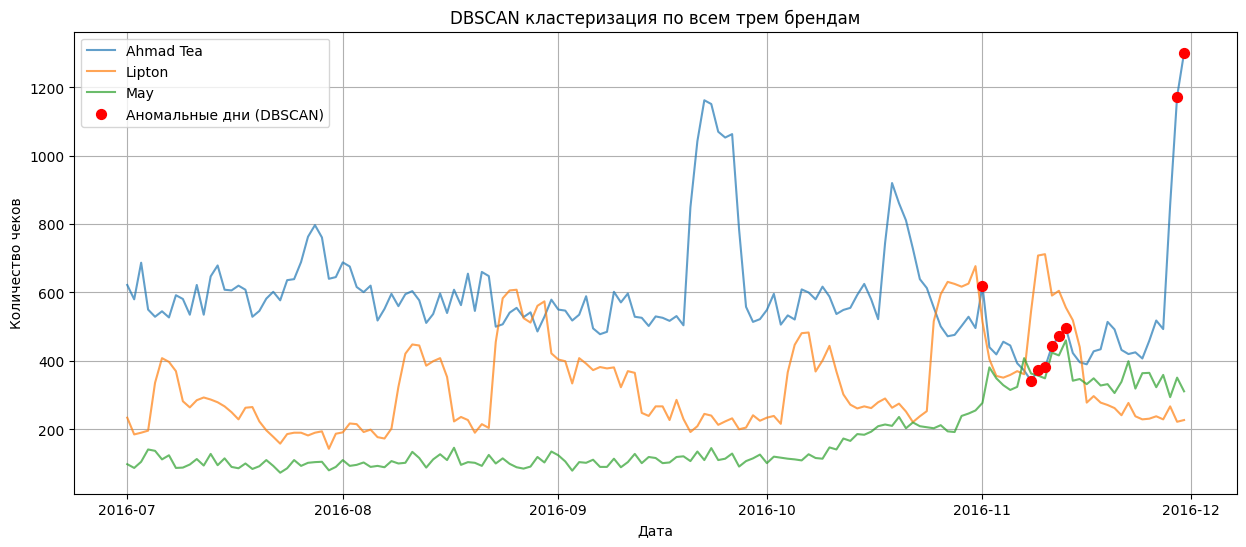

In [93]:
# Нормализуем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_data)

# Применяем DBSCAN.
dbscan = DBSCAN(eps=0.8, min_samples=5)
cluster_labels_dbscan = dbscan.fit_predict(X_scaled)

# Добавляем результаты в DataFrame
pivot_data["cluster_dbscan"] = cluster_labels_dbscan

# Аномалии - это точки, помеченные как -1
anomalies_dbscan = pivot_data[pivot_data["cluster_dbscan"] == -1]

# Выводим результаты
print(f"\nКоличество аномалий DBSCAN (все бренды): {len(anomalies_dbscan)}")
print(
    f"Количество кластеров: {len(set(cluster_labels_dbscan)) - (1 if -1 in cluster_labels_dbscan else 0)}"
)

# Визуализация результатов DBSCAN
plt.figure(figsize=(15, 6))
plt.plot(pivot_data.index, pivot_data["Ahmad_Tea"], label="Ahmad Tea", alpha=0.7)
plt.plot(pivot_data.index, pivot_data["Lipton"], label="Lipton", alpha=0.7)
plt.plot(pivot_data.index, pivot_data["May"], label="May", alpha=0.7)

if len(anomalies_dbscan) > 0:
    plt.scatter(
        anomalies_dbscan.index,
        anomalies_dbscan["Ahmad_Tea"],
        color="red",
        s=50,
        label="Аномальные дни (DBSCAN)",
        zorder=5,
    )

plt.title("DBSCAN кластеризация по всем трем брендам")
plt.xlabel("Дата")
plt.ylabel("Количество чеков")
plt.legend()
plt.grid(True)
plt.show()

#### 3. Поиск аномалий с помощью Isolation Forest

Этот алгоритм эффективно изолирует аномалии, так как они требуют меньше "разделений" для изоляции в дереве решений.


Количество аномалий Isolation Forest (все бренды): 8


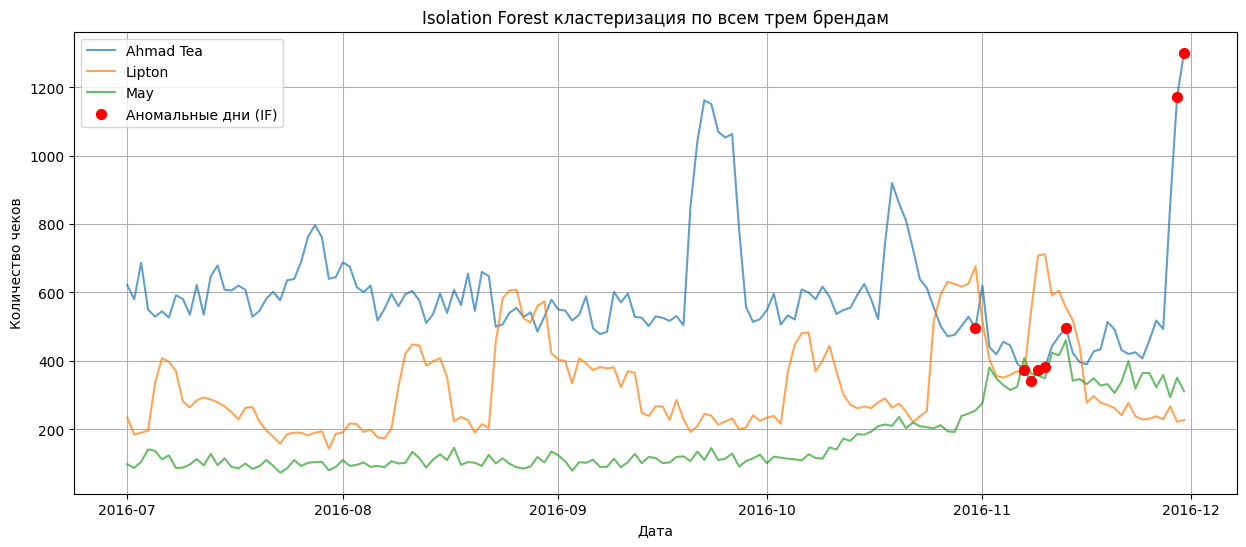

In [94]:
# Применяем Isolation Forest к тем же нормализованным данным
model_if_all = IsolationForest(contamination=0.05, random_state=42)
if_labels = model_if_all.fit_predict(X_scaled)

# Добавляем результаты в DataFrame
pivot_data["anomaly_if"] = if_labels

# Аномалии - это точки, помеченные как -1
anomalies_if_all = pivot_data[pivot_data["anomaly_if"] == -1]

# Выводим результаты
print(f"\nКоличество аномалий Isolation Forest (все бренды): {len(anomalies_if_all)}")

# Визуализация результатов Isolation Forest
plt.figure(figsize=(15, 6))
plt.plot(pivot_data.index, pivot_data["Ahmad_Tea"], label="Ahmad Tea", alpha=0.7)
plt.plot(pivot_data.index, pivot_data["Lipton"], label="Lipton", alpha=0.7)
plt.plot(pivot_data.index, pivot_data["May"], label="May", alpha=0.7)

if len(anomalies_if_all) > 0:
    plt.scatter(
        anomalies_if_all.index,
        anomalies_if_all["Ahmad_Tea"],
        color="red",
        s=50,
        label="Аномальные дни (IF)",
        zorder=5,
    )

plt.title("Isolation Forest кластеризация по всем трем брендам")
plt.xlabel("Дата")
plt.ylabel("Количество чеков")
plt.legend()
plt.grid(True)
plt.show()

### Заключение по кластеризации

#### Результаты применения методов кластеризации:

* **DBSCAN** выявил 9 аномальных дней в продажах всех трех брендов. Алгоритм обнаружил 4 основных кластера данных и выделил 9 точек как шум, что соответствует аномалиям.

* **Isolation Forest** обнаружил 8 аномальных паттернов продаж, что очень близко к результатам DBSCAN.

Аномалии, найденные обоими методами, не коррелируют с датами рекламных эфиров "Что? Где? Когда?". DBSCAN и Isolation Forest выделили общие пики продаж, которые являются естественными аномальными всплесками, но не связаны с внешним рекламным событием.

#### Вывод:
Кластерный анализ, проведенный на данных по всем трем вендорам, подтвердил результаты предыдущих методов. Он не выявил систематического влияния рекламы на продажи, так как аномалии, обнаруженные алгоритмами, представляют собой единичные, но значительные всплески, которые не приходятся исключительно на дни рекламных кампаний.